# <center>Limited dependent variables: Tobit and selection models</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Recognize the two distinct sources of dependent-variable limitation, *censoring* (the latent outcome is observed only above a threshold) and *sample selection* (the outcome is observed only for a non-random subsample), and identify the statistical consequences of each for OLS.

* Derive the Tobit log-likelihood as a mix of a point mass at the censoring threshold and a Gaussian density above it, and estimate Tobit by MLE.

* State the Heckman (1979) sample-selection model and derive the conditional mean correction $\mathbb{E}[y\mid d=1, x, w] = x^\top\beta + \rho\sigma\,\lambda(w^\top\gamma)$ involving the inverse Mills ratio $\lambda$.

* Implement Heckman's two-step procedure, probit on the full sample to estimate $\gamma$ and the inverse Mills ratio, then OLS on the selected subsample with the IMR as an additional regressor, and the joint MLE.

* Apply both methods to the Mroz (1987) labor-supply data and contrast the corrected wage equation with the naive OLS that ignores selection.

* Understand the role of the exclusion restriction in the identification of the selection model, and why selection models are notoriously sensitive to specification choices.

### References

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapter 24.

**[Heck]** Heckman, J. J. (1979). 'Sample Selection Bias as a Specification Error'. *Econometrica*, 47(1), 153–161.

**[T]** Tobin, J. (1958). 'Estimation of Relationships for Limited Dependent Variables'. *Econometrica*, 26(1), 24–36.

**[M]** Mroz, T. A. (1987). 'The Sensitivity of an Empirical Model of Married Women's Hours of Work to Economic and Statistical Assumptions'. *Econometrica*, 55(4), 765–799.

**[Am]** Amemiya, T. (1984). 'Tobit Models: A Survey'. *Journal of Econometrics*, 24(1–2), 3–61.

**[Wo]** Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data*, 2nd edition. MIT Press. Chapter 19.

# Motivation: when the outcome is partially observed

* Most economic outcomes are not observed cleanly on the whole population. Wages are observed only for people who work. Hours worked are observed at zero for non-workers (a corner solution). Expenditures on a particular good are zero for households that don't purchase the good. Donations, tax payments, prison sentences, durations: all share the property that the dependent variable is either censored, truncated, or selectively observed.

* OLS applied to such data, ignoring the limitation, is generally inconsistent for the parameters of the underlying *latent* model. The classic illustration is Mroz (1987): regressing log-wage on education using only the working subsample gives an OLS coefficient that confounds the causal return to education with the *selection* of women into the labor force, since women with low education and few outside options may participate at different rates than women with more education.

* This lecture develops the standard parametric corrections for these limitations, Tobit for censoring, Heckman for selection, and applies them to the Mroz sample. The Mroz data was assembled to study these issues, and the substantive question of women's wage determination remains a leading empirical application of the methods we develop here.

## Loading our libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from types import SimpleNamespace
import statsmodels.api as sm

rng = np.random.default_rng(777)
plt.rcParams['figure.figsize'] = (8, 4.5)


In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
print(f'Total observations:        {len(mroz)}')
print(f'In labor force (lfp = 1):  {(mroz["lfp"] == 1).sum()}')
print(f'Out of labor force:         {(mroz["lfp"] == 0).sum()}')
print()
print(f'Wage variable for non-workers (lfp = 0):')
print(mroz.loc[mroz['lfp'] == 0, 'wage'].describe())


Total observations:        753
In labor force (lfp = 1):  428
Out of labor force:         325

Wage variable for non-workers (lfp = 0):
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: wage, dtype: float64


Non-working women have `wage = 0` (a censored value), not an observed offered wage. The full sample has 753 women; only 428 have an observed wage. This gives the setup for both Tobit (treating 0 wages as censored at the participation margin) and Heckman selection (treating the 325 non-workers' wages as unobserved).

# 1. Censoring vs sample selection

## 1.1 Censored regression

Let $y_i^*$ be a latent variable generated by $y_i^* = x_i^\top\beta + \varepsilon_i$ with $\varepsilon_i\sim\mathcal{N}(0,\sigma^2)$. Suppose we observe
$$
y_i = \max(c,\;y_i^*),
$$
where $c$ is a known censoring threshold (e.g., $c=0$). All $I$ observations are kept in the sample; the dependent variable is just bounded below by $c$.

OLS of $y$ on $x$ confuses $y$ with $y^*$, attenuating the slope coefficient: marginal effects are diluted by the mass of observations at the censoring threshold. The right estimator is **Tobit** (Tobin 1958), which writes a likelihood for each observation that reflects whether $y_i > c$ (density of $y_i^*$ at $y_i$) or $y_i = c$ (probability mass $\mathbb{P}(y_i^* \leq c)$).

## 1.2 Sample selection

In the selection problem, two distinct equations operate jointly. A *selection* equation determines whether $y_i$ is observed:
$$
d_i = \mathbf{1}\{w_i^\top\gamma + \eta_i > 0\}, \qquad \eta_i\sim\mathcal{N}(0,1).
$$
An *outcome* equation determines $y_i$ when $d_i = 1$:
$$
y_i = x_i^\top\beta + \varepsilon_i, \qquad \varepsilon_i\sim\mathcal{N}(0,\sigma^2).
$$
We observe $w_i$ for all $i$ and $(x_i, y_i)$ only when $d_i = 1$. If $\varepsilon$ and $\eta$ are correlated, the conditional distribution of $\varepsilon$ given $d=1$ is shifted, and OLS on the selected sample is inconsistent: the classical Heckman (1979) sample-selection bias.

Censoring and selection are not the same thing. In censoring, all units are observed but some values are capped at $c$. In selection, some units' outcomes are unobserved entirely. The choice between the two models is substantive: when a non-worker's "wage" is the offered wage that was rejected, selection is the right model; when it really is zero (a corner solution), Tobit may be appropriate.

# 2. The Tobit model

## 2.1 Log-likelihood

Under censoring at $c$ with $\varepsilon_i\sim\mathcal{N}(0,\sigma^2)$:
$$
\ell_i(\beta,\sigma) = \mathbf{1}\{y_i > c\}\bigl[-\log\sigma - \tfrac{1}{2}\log(2\pi) - \tfrac{1}{2}(z_i)^2\bigr] + \mathbf{1}\{y_i = c\}\log\Phi\bigl(\tfrac{c - x_i^\top\beta}{\sigma}\bigr),
$$
where $z_i := (y_i - x_i^\top\beta)/\sigma$. The first term is the Gaussian log-density at uncensored observations; the second is the log-probability mass $\mathbb{P}(y_i^*\leq c\mid x_i)$ at censored observations.

The likelihood is log-concave in $(\beta,\sigma^{-1})$ (Amemiya 1984), so a Newton-type optimizer reliably finds the global maximum from any reasonable starting value.

## 2.2 DIY estimation

In [3]:
def tobit_loglik(θ, X_i_k, y_i, c=0.0):
    # θ = [β_k (K), log_σ (1)]
    β_k    = θ[:-1]
    σ      = np.exp(θ[-1])
    Xβ_i   = X_i_k @ β_k
    obs_i  = (y_i > c)
    # Evaluate each piece only on its support to avoid 0·(-inf) = NaN
    loglik_i = np.zeros(len(y_i))
    if obs_i.any():
        z_i = (y_i[obs_i] - Xβ_i[obs_i]) / σ
        loglik_i[obs_i] = -np.log(σ) - 0.5 * np.log(2*np.pi) - 0.5 * z_i**2
    if (~obs_i).any():
        arg_i = (c - Xβ_i[~obs_i]) / σ
        loglik_i[~obs_i] = stats.norm.logcdf(arg_i)
    return loglik_i.sum()

def tobit_mle(X_i_k, y_i, c=0.0, βinit_k=None, log_σ_init=0.0):
    if βinit_k is None:
        βinit_k = np.zeros(X_i_k.shape[1])
    θ0 = np.r_[βinit_k, log_σ_init]
    # Nelder-Mead is gradient-free and more robust on this poorly-scaled problem
    # than BFGS with finite-difference gradients.
    res = optimize.minimize(
        fun=lambda θ: -tobit_loglik(θ, X_i_k, y_i, c),
        x0=θ0,
        method='Nelder-Mead',
        options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 20_000, 'adaptive': True},
    )
    βhat_k = res.x[:-1]
    σ_hat = np.exp(res.x[-1])
    return SimpleNamespace(β_k=βhat_k, σ=σ_hat, log_lik=-res.fun, res=res)


## 2.3 Application to Mroz wages

We treat the hourly wage as censored at zero for non-working women: i.e., we are imagining that the offered wage existed but was simply below the woman's reservation wage and so she did not work. (Whether this is the right substantive model for the Mroz data is the question §3 addresses; we'll come back to it.)

In [4]:
y_i = mroz['wage'].values                    # 0 for non-workers, positive otherwise
I = len(mroz)
X_i_k = np.column_stack([
    np.ones(I),
    mroz['educ'].values,
    mroz['exper'].values,
    mroz['exper'].values ** 2,
])
xnames = ['const', 'educ', 'exper', 'exper^2']

# Naive OLS on working women only (the wrong way)
working_i = (y_i > 0)
βolsw_k = np.linalg.solve(X_i_k[working_i].T @ X_i_k[working_i], X_i_k[working_i].T @ y_i[working_i])

# Tobit MLE on the full sample with censoring at 0
fit_tobit = tobit_mle(X_i_k, y_i, c=0.0, βinit_k=βolsw_k, log_σ_init=np.log(3.0))

print(f"{'name':<10s}{'OLS (working only)':>22s}{'Tobit MLE':>14s}")
for name, b1, b2 in zip(xnames, βolsw_k, fit_tobit.β_k):
    print(f'{name:<10s}{b1:>22.4f}{b2:>14.4f}')
print(f'{"σ":<10s}{"—":>22s}{fit_tobit.σ:>14.4f}')


name          OLS (working only)     Tobit MLE
const                    -2.4880      -10.4129
educ                      0.4957        0.6389
exper                     0.0367        0.4601
exper^2                  -0.0004       -0.0090
σ                              —        4.4639


The Tobit coefficients on education and experience are visibly larger in magnitude than the OLS coefficients on working women: $\hat\beta_{\text{educ}}$ moves from $0.50$ (naive OLS) to $0.64$ (Tobit), and $\hat\beta_{\text{exper}}$ jumps an order of magnitude. This is the diluting bias one would expect from treating censored observations as if they were genuinely zero outcomes; the Tobit corrects for the latent-variable interpretation. The estimated $\hat\sigma \approx 4.5$ is the standard deviation of the latent offered wage, on a scale where observed wages range from $\$0$ to $\$25$.

However: Tobit's interpretation here is conceptually shaky. The non-workers' "wage = 0" is not a genuine zero outcome; it is an *unobserved* offered wage. The right framework is Heckman selection, not Tobit. We turn to that now.

# 3. Heckman's two-step selection correction

## 3.1 The conditional mean correction

Assume $(\varepsilon_i, \eta_i)\sim\mathcal{N}(0,\Sigma)$ with $\Sigma = \begin{pmatrix}\sigma^2 & \rho\sigma\\ \rho\sigma & 1\end{pmatrix}$. The relevant identity for the bivariate normal distribution is

$$
\mathbb{E}[\varepsilon_i\mid \eta_i > -w_i^\top\gamma] = \rho\sigma\cdot\lambda(w_i^\top\gamma),
$$

where $\lambda(z) := \phi(z)/\Phi(z)$ is the **inverse Mills ratio**. Substituting into the outcome equation,
$$
\mathbb{E}[y_i\mid d_i = 1, x_i, w_i] = x_i^\top\beta + \rho\sigma\,\lambda(w_i^\top\gamma).
$$
The selection problem becomes an *omitted variable* problem: OLS on the working subsample, without including $\lambda(w_i^\top\gamma)$ on the right-hand side, leaves $\lambda$ in the residual and (since $\lambda$ is correlated with $x$ through $w$ and $\gamma$) biases the OLS coefficient on $x$.

## 3.2 Heckman's two-step procedure

Heckman (1979) proposed estimating the model in two stages:

1. **Probit on the full sample.** Estimate $\hat\gamma$ from the probit of $d_i$ on $w_i$. Compute the inverse Mills ratio $\hat\lambda_i = \phi(w_i^\top\hat\gamma)/\Phi(w_i^\top\hat\gamma)$ for working women.

2. **OLS on the selected subsample.** Regress $y_i$ on $x_i$ and $\hat\lambda_i$ for $i$ with $d_i = 1$. The coefficient on $\hat\lambda_i$ is an estimate of $\rho\sigma$; the coefficient on $x_i$ is the bias-corrected $\hat\beta$.

The procedure is consistent under the joint normality assumption. The standard errors from the second-stage OLS are wrong, however: they ignore both the heteroskedasticity induced by the IMR correction and the first-stage estimation uncertainty in $\hat\gamma$. We use White-style robust SEs as a first-pass correction (Lecture 4, §3); for the asymptotically correct formula see Heckman (1979) Appendix or Wooldridge ch. 19.

In [5]:
def probit_mle(W_i_l, d_i):
    # Maximum-likelihood probit by direct optimization.
    def negll(γ_l):
        Wγ_i = W_i_l @ γ_l
        ll_i = d_i * stats.norm.logcdf(Wγ_i) + (1 - d_i) * stats.norm.logcdf(-Wγ_i)
        return -ll_i.sum()

    γ0_l = np.zeros(W_i_l.shape[1])
    res = optimize.minimize(negll, γ0_l, method='BFGS', options={'gtol': 1e-8})
    return res.x

def heckman_two_step(X_i_k, y_i, W_i_l, d_i):
    # Step 1: probit
    γ_l = probit_mle(W_i_l, d_i)
    # Step 2: inverse Mills ratio
    Wγ_i = W_i_l @ γ_l
    λ_i = stats.norm.pdf(Wγ_i) / np.maximum(stats.norm.cdf(Wγ_i), 1e-300)
    # Step 3: OLS on selected sample with λ as additional regressor
    sel_i = (d_i == 1)
    Z_s_k = np.column_stack([X_i_k[sel_i], λ_i[sel_i]])
    coef_k = np.linalg.solve(Z_s_k.T @ Z_s_k, Z_s_k.T @ y_i[sel_i])
    β_k   = coef_k[:-1]
    θ_imr = coef_k[-1]                      # ρ·σ
    # White-robust SEs (under-corrects for first-stage uncertainty, but a useful baseline)
    εhat_s  = y_i[sel_i] - Z_s_k @ coef_k
    ZtZinv_k_k = np.linalg.inv(Z_s_k.T @ Z_s_k)
    Ω_k_k = (Z_s_k * (εhat_s ** 2)[:, None]).T @ Z_s_k
    V_k_k = ZtZinv_k_k @ Ω_k_k @ ZtZinv_k_k
    se_k = np.sqrt(np.diag(V_k_k))
    return SimpleNamespace(β_k=β_k, θ_imr=θ_imr, γ_l=γ_l, se_k=se_k, λ=λ_i)


## 3.3 Application to Mroz log-wages

The outcome regressors are $(\text{const}, \text{educ}, \text{exper}, \text{exper}^2)$. The selection regressors include those *plus* the variables that affect labor force participation but are excluded from the outcome equation: `kids5`, `kids618`, `age`, `nwifeinc`. The exclusion restriction is the credible identification content of the model: variables that determine whether a woman works without directly influencing her offered wage.

In [6]:
d_i = mroz['lfp'].values
ylog_i = np.where(d_i == 1, np.log(np.maximum(mroz['wage'].values, 1e-10)), 0.0)

# Outcome equation: educ + exper + expersq + const
X_i_k = np.column_stack([
    np.ones(I),
    mroz['educ'].values,
    mroz['exper'].values,
    mroz['exper'].values ** 2,
])

# Selection equation: same as outcome plus the exclusion variables
W_i_l = np.column_stack([
    np.ones(I),
    mroz['educ'].values,
    mroz['exper'].values,
    mroz['exper'].values ** 2,
    mroz['kids5'].values,
    mroz['kids618'].values,
    mroz['age'].values,
    mroz['nwifeinc'].values,
])
wnames = xnames + ['kids5', 'kids618', 'age', 'nwifeinc']

fit_2step = heckman_two_step(X_i_k, ylog_i, W_i_l, d_i)

# Naive OLS on working women only
sel_i = (d_i == 1)
βolsnaive_k = np.linalg.solve(X_i_k[sel_i].T @ X_i_k[sel_i], X_i_k[sel_i].T @ ylog_i[sel_i])

print(f"{'name':<10s}{'naive OLS':>14s}{'Heckman 2-step':>18s}{'(s.e.)':>10s}")
for j, name in enumerate(xnames):
    print(f'{name:<10s}{βolsnaive_k[j]:>14.4f}{fit_2step.β_k[j]:>18.4f}{fit_2step.se_k[j]:>10.4f}')
print(f'{"λ̂ (=ρσ)":<10s}{"—":>14s}{fit_2step.θ_imr:>18.4f}{fit_2step.se_k[-1]:>10.4f}')


name           naive OLS    Heckman 2-step    (s.e.)
const            -0.5220           -0.5781    0.2958
educ              0.1075            0.1091    0.0148
exper             0.0416            0.0439    0.0157
exper^2          -0.0008           -0.0009    0.0004
λ̂ (=ρσ)               —            0.0323    0.1618


Let us look directly at the correction term. The inverse Mills ratio $\lambda(w_i^\top\hat\gamma) = \phi(\cdot)/\Phi(\cdot)$ is a decreasing, convex function of the selection index: it is large for women the first stage says are *unlikely* to work, and near zero for those almost certain to. Since only workers enter the second stage, the fitted $\hat\lambda$ on that subsample spans a limited range, which is why the exclusion restriction of §6 matters. Without one, $\hat\lambda$ is a smooth function of the same regressors already in the outcome equation, and the correction is identified only off its curvature.

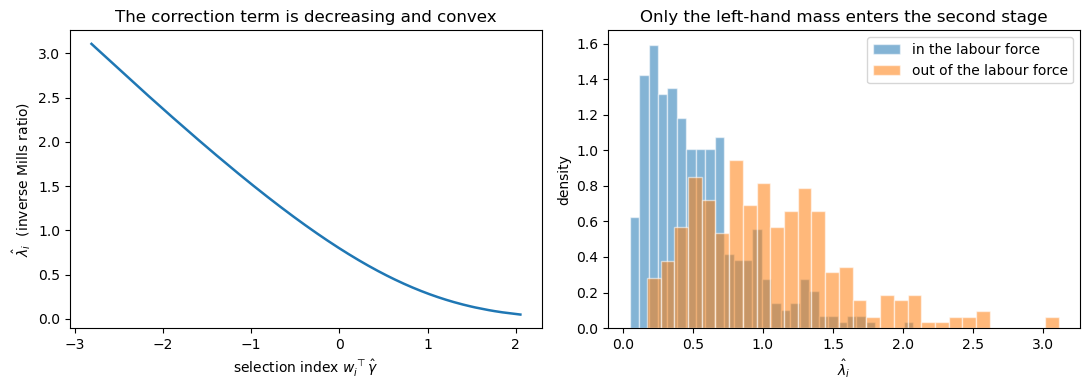

λ̂ among workers:     mean 0.530, range [0.050, 2.070]
λ̂ among non-workers: mean 1.033, range [0.172, 3.107]


In [7]:
index_i = W_i_l @ fit_2step.γ_l
worker = (d_i == 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
order = np.argsort(index_i)
axes[0].plot(index_i[order], fit_2step.λ[order], lw=1.8)
axes[0].set_xlabel(r'selection index $w_i^\top\hat\gamma$')
axes[0].set_ylabel(r'$\hat\lambda_i$  (inverse Mills ratio)')
axes[0].set_title('The correction term is decreasing and convex')

axes[1].hist(fit_2step.λ[worker], bins=30, density=True, alpha=0.55,
             edgecolor='white', label='in the labour force')
axes[1].hist(fit_2step.λ[~worker], bins=30, density=True, alpha=0.55,
             edgecolor='white', label='out of the labour force')
axes[1].set_xlabel(r'$\hat\lambda_i$')
axes[1].set_ylabel('density')
axes[1].set_title('Only the left-hand mass enters the second stage')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'λ̂ among workers:     mean {fit_2step.λ[worker].mean():.3f}, range [{fit_2step.λ[worker].min():.3f}, {fit_2step.λ[worker].max():.3f}]')
print(f'λ̂ among non-workers: mean {fit_2step.λ[~worker].mean():.3f}, range [{fit_2step.λ[~worker].min():.3f}, {fit_2step.λ[~worker].max():.3f}]')


The coefficient on the inverse Mills ratio is small and positive ($\hat\theta_{\lambda}\approx 0.03$)
with a standard error of about $0.16$, so it is nowhere near distinguishable from zero: the data
give little evidence of selection on unobservables in this specification.

A caveat on that standard error. It is the White covariance for the *second-stage* regression, which treats the first-stage $\hat\gamma$, and therefore $\hat\lambda_i$, as if it were known data rather than estimated. It is therefore **not** the correct two-step standard error. The proper one (Heckman 1979) differs in two ways at once: it adds a term for first-stage estimation uncertainty, and it accounts for the induced heteroskedasticity of the second-stage error through a factor involving $\rho^2$. Those two adjustments push in opposite directions, so **we cannot say from here which way the corrected standard error would move** without computing it or bootstrapping the whole two-step procedure, and this notebook does neither.

What can be said without that computation is narrower, and rests on the point estimate rather than on its standard error: $\hat\theta_\lambda \approx 0.03$ on a coefficient scale where the outcome coefficients are around $0.1$, which is a small estimated selection effect however its uncertainty is measured. The MLE in §4, which does not rely on this covariance at all, reaches the same reading.

Subtracting the selection correction shifts the outcome coefficients very little: the return to
education moves from $\hat\beta_{\text{educ}}^{\text{OLS}} = 0.1075$ to
$\hat\beta_{\text{educ}}^{\text{Heck}} = 0.1091$, a change of $0.0016$ log points. The economic
substance: in the Mroz data, ignoring selection does not appreciably bias the estimated return to
schooling: a finding echoed through much of the subsequent literature.

# 4. Heckman MLE

The two-step procedure is consistent but not efficient: its inverse-Mills-ratio approximation throws away information from the joint distribution of $(d, y)$. The fully efficient estimator maximizes the joint likelihood
$$
\ell(\beta,\gamma,\sigma,\rho) = \sum_{i:d_i = 0}\log\Phi(-w_i^\top\gamma) + \sum_{i:d_i = 1}\Bigl[\log\phi\bigl(\tfrac{y_i - x_i^\top\beta}{\sigma}\bigr) - \log\sigma + \log\Phi\bigl(\tfrac{w_i^\top\gamma + \rho(y_i - x_i^\top\beta)/\sigma}{\sqrt{1-\rho^2}}\bigr)\Bigr].
$$
The first sum is the marginal probability of non-participation; the second is the joint density at the observed $(y, d=1)$.

Numerical optimization is delicate because of constraints ($\sigma > 0$, $\rho\in(-1,1)$). We reparameterize: $\sigma = e^{\log\sigma}$ and $\rho = \tanh(\xi)$ for unrestricted $\xi$.

In [8]:
def heckman_loglik_full(θ, X_i_k, y_i, W_i_l, d_i, K, L):
    β_k       = θ[:K]
    γ_l       = θ[K:K + L]
    log_σ   = θ[-2]
    ξ       = θ[-1]
    σ       = np.exp(log_σ)
    ρ       = np.tanh(ξ)

    Wγ_i      = W_i_l @ γ_l
    lognon_i = stats.norm.logcdf(-Wγ_i)                       # for d = 0 observations
    z_i       = (y_i - X_i_k @ β_k) / σ
    arg_i     = (Wγ_i + ρ * z_i) / np.sqrt(1 - ρ**2 + 1e-12)
    logyes_i = (- log_σ - 0.5 * np.log(2*np.pi) - 0.5 * z_i**2 + stats.norm.logcdf(arg_i))

    return np.sum((1 - d_i) * lognon_i + d_i * logyes_i)

def heckman_mle(X_i_k, y_i, W_i_l, d_i, init_2step):
    K, L = X_i_k.shape[1], W_i_l.shape[1]
    # Initialization: 2-step β, probit γ, and ρ·σ from the IMR coefficient
    σ_init = np.std(y_i[d_i == 1] - X_i_k[d_i == 1] @ init_2step.β_k) or 1.0
    log_σ0 = np.log(σ_init)
    ρ_init = np.clip(init_2step.θ_imr / σ_init, -0.95, 0.95)
    ξ_init = np.arctanh(ρ_init)
    θ0 = np.r_[init_2step.β_k, init_2step.γ_l, log_σ0, ξ_init]

    negll = lambda θ: -heckman_loglik_full(θ, X_i_k, y_i, W_i_l, d_i, K, L)
    # Nelder-Mead, for the same reason as the Tobit fit above: BFGS on this badly scaled
    # likelihood stops with status 2 ('precision loss') and never certifies convergence.
    res = optimize.minimize(negll, θ0, method='Nelder-Mead',
                            options={'xatol': 1e-9, 'fatol': 1e-11,
                                     'maxiter': 80_000, 'maxfev': 80_000, 'adaptive': True})
    res = optimize.minimize(negll, res.x, method='Nelder-Mead',      # one polishing restart
                            options={'xatol': 1e-9, 'fatol': 1e-11,
                                     'maxiter': 80_000, 'maxfev': 80_000, 'adaptive': True})
    β_k = res.x[:K]
    γ_l = res.x[K:K + L]
    σ   = np.exp(res.x[-2])
    ρ   = np.tanh(res.x[-1])

    # Observed information by central differences, so that ρ̂ can be given a standard error
    # instead of being called insignificant by eye.
    def num_hessian(f, x, h=1e-5):
        n = len(x)
        H = np.empty((n, n))
        for a in range(n):
            for b in range(a, n):
                ea, eb = np.zeros(n), np.zeros(n)
                ea[a] = h
                eb[b] = h
                H[a, b] = H[b, a] = (f(x+ea+eb) - f(x+ea-eb)
                                     - f(x-ea+eb) + f(x-ea-eb)) / (4*h*h)
        return H

    V_p_p = np.linalg.inv(num_hessian(negll, res.x))
    se_ξ  = np.sqrt(V_p_p[-1, -1])
    se_ρ  = (1 - ρ**2) * se_ξ            # delta method through ρ = tanh(ξ)
    se_β_k = np.sqrt(np.diag(V_p_p)[:K])
    return SimpleNamespace(β_k=β_k, γ_l=γ_l, σ=σ, ρ=ρ, se_ρ=se_ρ, se_β_k=se_β_k,
                           log_lik=-res.fun, res=res)

fit_mle = heckman_mle(X_i_k, ylog_i, W_i_l, d_i, init_2step=fit_2step)

print(f'optimizer: success = {fit_mle.res.success}  (status {fit_mle.res.status})')
print(f'   message = {fit_mle.res.message}')
print(f'   function evaluations = {fit_mle.res.nfev}\n')

print(f"{'name':<10s}{'2-step β̂':>14s}{'MLE β̂':>14s}{'MLE s.e.':>12s}")
for name, b1, b2, s2 in zip(xnames, fit_2step.β_k, fit_mle.β_k, fit_mle.se_β_k):
    print(f'{name:<10s}{b1:>14.4f}{b2:>14.4f}{s2:>12.4f}')
print(f'\n{"σ̂":<10s}{"—":>14s}{fit_mle.σ:>14.4f}')
print(f'{"ρ̂":<10s}{fit_2step.θ_imr/fit_mle.σ:>14.4f}{fit_mle.ρ:>14.4f}{fit_mle.se_ρ:>12.4f}')
print(f'   ρ̂ / s.e.(ρ̂) = {fit_mle.ρ/fit_mle.se_ρ:.3f};  95% CI '
      f'[{fit_mle.ρ - 1.96*fit_mle.se_ρ:+.4f}, {fit_mle.ρ + 1.96*fit_mle.se_ρ:+.4f}]')
print(f'\nlog-likelihood at MLE = {fit_mle.log_lik:.4f}')

# ---------------------------------------------------------------------------------
# Verification. Nelder-Mead is derivative-free, so its success flag reports that the
# simplex collapsed — not that the score is zero. Check the first-order condition
# directly, and check that gradient-based methods cannot improve on the solution.
K_x, L_w = X_i_k.shape[1], W_i_l.shape[1]
negll_mle = lambda θ: -heckman_loglik_full(θ, X_i_k, ylog_i, W_i_l, d_i, K_x, L_w)
θhat_p = fit_mle.res.x

def central_gradient(f, x_p, h=1e-6):
    g_p = np.empty(len(x_p))
    for j in range(len(x_p)):
        e_p = np.zeros(len(x_p))
        e_p[j] = h
        g_p[j] = (f(x_p + e_p) - f(x_p - e_p)) / (2 * h)
    return g_p

g_p = central_gradient(negll_mle, θhat_p)
g_max = np.max(np.abs(g_p))
print(f'\nmax |∂(-log L)/∂θ| at the solution        = {g_max:.3e}')
print(f'   ... per observation (÷ I = {len(y_i)})           = {g_max/len(y_i):.3e}')

# Restart two gradient-based optimizers from the Nelder-Mead point.
for method, opts in (('BFGS', {'gtol': 1e-10, 'maxiter': 2000}),
                     ('L-BFGS-B', {'ftol': 1e-15, 'gtol': 1e-12, 'maxiter': 5000})):
    r = optimize.minimize(negll_mle, θhat_p, method=method, options=opts)
    print(f'   restart {method:<9s} Δ(-log L) = {r.fun - fit_mle.res.fun:+.2e}, '
          f'max |Δθ| = {np.max(np.abs(r.x - θhat_p)):.2e}')

assert fit_mle.res.success, 'Heckman MLE did not converge'
assert g_max / len(y_i) < 1e-4, f'score not close to zero: {g_max/len(y_i):.2e} per obs'
r_check = optimize.minimize(negll_mle, θhat_p, method='L-BFGS-B',
                            options={'ftol': 1e-15, 'gtol': 1e-12, 'maxiter': 5000})
assert r_check.fun >= fit_mle.res.fun - 1e-6, 'a gradient method found a better optimum'
assert np.max(np.abs(r_check.x - θhat_p)) < 1e-6, 'the solution is not stationary'
print('Verification passed: stationary point, and no gradient method improves on it.')


optimizer: success = True  (status 0)
   message = Optimization terminated successfully.
   function evaluations = 2410

name           2-step β̂        MLE β̂    MLE s.e.
const            -0.5781       -0.5527      0.2604
educ              0.1091        0.1084      0.0149
exper             0.0439        0.0428      0.0149
exper^2          -0.0009       -0.0008      0.0004

σ̂                     —        0.6634
ρ̂                0.0486        0.0266      0.1471
   ρ̂ / s.e.(ρ̂) = 0.181;  95% CI [-0.2617, +0.3149]

log-likelihood at MLE = -832.8851

max |∂(-log L)/∂θ| at the solution        = 2.443e-03
   ... per observation (÷ I = 753)           = 3.245e-06


   restart BFGS      Δ(-log L) = +0.00e+00, max |Δθ| = 0.00e+00
   restart L-BFGS-B  Δ(-log L) = +0.00e+00, max |Δθ| = 0.00e+00
Verification passed: stationary point, and no gradient method improves on it.


> **On reading the convergence evidence.** The raw gradient above looks large for a
> "converged" optimum, but it is the gradient of the log-likelihood *summed* over all
> $I$ observations: per observation it is around $10^{-6}$, which is the noise floor of a
> central finite difference at this step size. The more informative check is the second one: > two gradient-based optimizers started from this point cannot move it or improve the
> objective at all. That is the substitute for a conventional gradient tolerance, which a
> derivative-free method like Nelder-Mead never sets in the first place.

The MLE and the two-step agree to roughly the third decimal on the coefficients of substantive
interest, and the MLE puts $\hat\rho \approx 0.027$ against a standard error of about $0.15$: a $t$-statistic near $0.18$, with a 95% interval running from about $-0.26$ to $+0.31$. The
selection correlation is not merely small; it is estimated far too imprecisely to distinguish
from zero in either direction. That is a recurring finding on these data and the source of the
long-running debate over whether the Heckman correction matters here.

This agreement does **not** establish the following. It is tempting to read "two-step and MLE give
the same answer" as evidence that the joint-normality assumption is harmless, but the two
procedures are not independent tests of it: both are derived from the *same* bivariate normal
selection model, the two-step using the conditional-mean implication and the MLE the full
likelihood. They can only disagree through efficiency and finite-sample behaviour, never about
whether normality was the right assumption in the first place. Probing that requires a
semiparametric estimator that drops the distributional assumption; Powell (1984) or
Klein–Spady (1993), neither of which is developed in this series.

# 5. Side-by-side: OLS, Heckman two-step, and Heckman MLE

Tobit is deliberately absent from the table below. It was fitted to the wage *level* with
censoring at zero, while the three estimators compared here are fitted to the *log* wage among
workers, so their coefficients are not on a common scale and a shared column would invite a
comparison that means nothing. Tobit's own scale parameter is reported separately underneath.

In [9]:
# Convert Tobit β to log-wage scale: rough heuristic — Tobit was fit on wage,
# Heckman/OLS on log(wage). We can't directly compare them, so we drop Tobit
# from the table and report only the log-wage estimators side by side.

table = pd.DataFrame({
    'naive OLS':       βolsnaive_k,
    'Heckman 2-step':  fit_2step.β_k,
    'Heckman MLE':     fit_mle.β_k,
}, index=xnames).round(4)
print(table.to_string())
print(f'\nTobit (wage levels, not log): σ̂ = {fit_tobit.σ:.3f}')
print(f'Heckman 2-step:  ρσ = {fit_2step.θ_imr:.4f}')
print(f'Heckman MLE:     ρ  = {fit_mle.ρ:.4f},  σ = {fit_mle.σ:.4f},  ρσ = {fit_mle.ρ*fit_mle.σ:.4f}')


         naive OLS  Heckman 2-step  Heckman MLE
const      -0.5220         -0.5781      -0.5527
educ        0.1075          0.1091       0.1084
exper       0.0416          0.0439       0.0428
exper^2    -0.0008         -0.0009      -0.0008

Tobit (wage levels, not log): σ̂ = 4.464
Heckman 2-step:  ρσ = 0.0323
Heckman MLE:     ρ  = 0.0266,  σ = 0.6634,  ρσ = 0.0177


The three log-wage estimators agree closely: education raises log-wages by roughly $0.108$ log
points per year, about an 11% proportional return, the classical Mincer magnitude, and
experience enters with a concave profile.

The selection corrections barely move the education coefficient at all. Against the naive OLS
value of $0.1075$, the two-step gives $0.1091$ and the MLE $0.1084$: shifts of $0.0016$ and
$0.0009$ log points, or between one and two tenths of a percentage point on the estimated return
to a year of schooling. That is well inside the coefficient's own standard error of about
$0.015$, so the three estimates are statistically indistinguishable from one another.

This flatness across specifications is the substantive result rather than a disappointment: when
a finding survives the choice of selection-correction method, it deserves more credence than one
that depends on it. The textbook treatment of Mroz tends to emphasise how *little* the Heckman
correction moves these estimates, which is itself the empirical lesson. We should be precise
about what has and has not been shown, though: the corrections are small **given** joint
normality and the exclusion restriction of §6. They are not evidence that those assumptions hold.

# 6. Identification and the exclusion restriction

## 6.1 Why an exclusion restriction is essential

Without any restriction on which regressors enter the outcome vs. selection equations, the Heckman model is identified only through the *nonlinearity* of the inverse Mills ratio: the IMR is a (highly nonlinear) function of $w^\top\gamma$, so its inclusion does not lead to perfect collinearity with $X$ even when $W = X$. This is, however, a fragile form of identification: it relies entirely on the functional-form assumption of joint normality, which is exactly the assumption one would like to relax.

The standard recommendation is to ensure that $W$ contains at least one variable not in $X$, an *exclusion restriction*. In our Mroz specification, the exclusion variables are `kids5`, `kids618`, `age`, `nwifeinc`, factors that affect labor force participation without (under the standard assumption) directly affecting the wage rate.

## 6.2 Sensitivity to the exclusion restriction

To illustrate the importance of the exclusion restriction, we re-run the Heckman two-step *without* the exclusion variables, i.e., with $W = X$, and compare the resulting estimates.

In [10]:
# Identification only through IMR nonlinearity (W = X)
fit_2step_X = heckman_two_step(X_i_k, ylog_i, X_i_k, d_i)
print(f"Selection equation = outcome equation (no exclusion restriction):")
print(f"{'name':<10s}{'with excl.':>14s}{'without excl.':>16s}{'change':>10s}")
for j, name in enumerate(xnames):
    diff = fit_2step_X.β_k[j] - fit_2step.β_k[j]
    print(f'{name:<10s}{fit_2step.β_k[j]:>14.4f}{fit_2step_X.β_k[j]:>16.4f}{diff:>+10.4f}')
print(f'{"λ̂ coef":<10s}{fit_2step.θ_imr:>14.4f}{fit_2step_X.θ_imr:>16.4f}')


Selection equation = outcome equation (no exclusion restriction):
name          with excl.   without excl.    change
const            -0.5781         -0.0104   +0.5677
educ              0.1091          0.0935   -0.0156
exper             0.0439          0.0208   -0.0231
exper^2          -0.0009         -0.0004   +0.0005
λ̂ coef           0.0323         -0.2702


The two specifications give visibly different estimates: with the exclusion restriction, $\hat\beta_{\text{educ}} = 0.109$ and $\hat\beta_{\text{exper}} = 0.044$; *without* it, $\hat\beta_{\text{educ}} = 0.094$ and $\hat\beta_{\text{exper}} = 0.021$: a halving of the experience coefficient. The IMR coefficient itself flips sign (from $+0.03$ to $-0.27$).

Thus, even when the IMR's nonlinearity provides formal identification in the absence of an exclusion restriction, the estimates can be sensitive to whether the selection equation has *independent* variation from the outcome equation. Reporting both specifications, with and without the exclusion restriction, is a standard robustness check in applied work; the gap between them tells the reader how much identification rests on the (untestable) joint-normality assumption.

# Looking ahead

The parametric corrections in this lecture, Tobit and Heckman, rest squarely on the normality of $\varepsilon$ and on the joint normality of $(\varepsilon, \eta)$. Two natural directions to extend:

* **Semiparametric selection.** Powell's (1984) symmetrically trimmed least squares and the Klein–Spady (1993) semi-parametric MLE estimate the selection correction nonparametrically, avoiding the joint-normality assumption at the cost of slower convergence rates. Neither is developed in this series. The modern double/debiased-ML literature applies machine-learning estimators of the nuisance components (the propensity score and the conditional outcome), which is the right tool for the high-dimensional version of the problem; **Lecture 13** develops the orthogonality-and-cross-fitting machinery it rests on.

* **The Roy model and matching with selection.** Mroz's labor supply application can be viewed as a special case of a more general model in which individuals self-select into one of several activities (work / not work; one occupation / another), with rewards in each that depend on observable and unobservable characteristics. The Roy model develops these ideas in the matching-markets framework: a thread that connects directly to the optimal-transport and discrete-choice notebooks in the broader math+econ+code series.

The Mroz dataset, finally, has been with us since Lecture 1. After fourteen lectures, we have applied virtually every tool in the standard econometric toolkit to it: descriptive statistics, OLS, robust inference, panel-data (in the related wagepan sample), IV, the Heckman correction, MLE, and the comparison of all of these against each other. The deep purpose of working with one dataset for fourteen lectures is not the dataset itself, but the discipline of letting each method illuminate a different feature of the same underlying structural question: what determines wages, and what determines who works?